In [1]:
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, Agilent, ThorlabsPM
from Equipments.MCBOX import generate_test_voltages
from DataProcessing.Plot import PlotSaver
import numpy as np
import pyvisa
import time
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [3]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB0::0x1313::0x807B::241023118::0::INSTR')


In [4]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


In [5]:
bias_channel = 11

In [40]:
mcbox.set_voltage_1chan(channel = bias_channel, voltage = -1, bipolar = True, display = True)

Channel 11 has been set to -1 V.


In [10]:
agilent = Agilent.Agilent('TCPIP0::169.254.110.10::inst0::INSTR',power_limit=0, freq_limit=38e9)

Agilent Technologies, N5183A, MY47420242, A.01.43



In [8]:
pm = ThorlabsPM.ThorlabsPM('USB0::0x1313::0x807B::241023118::0::INSTR')

Thorlabs,PM16-130,241023118,1.6.0



In [52]:
pm.readout(wavelength = 1064)

0.008379126

In [13]:
agilent.set_frequency(frequency = 38e9)

In [51]:
agilent.set_power(-80)

In [62]:
agilent.set_power_limit(2)

In [67]:
agilent.inst.close()

In [63]:
output_power = []
RF_power_list = np.linspace(-20, 2, 41) # [dBm]
bias_list = np.linspace(-5,5,41) # [V]
bias_channel = 11  # added this
print(RF_power_list)
print(bias_list)

agilent.set_frequency(frequency = 38e9)  # changed from 10 GHz
agilent.set_power(RF_power_list[0])
agilent.start_output()

for RF_power in RF_power_list:
    print(f"Now checking {RF_power}dBm")
    agilent.set_power(RF_power)
    time.sleep(1)
    sub_output_power = []
    for bias in bias_list:
        mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
        time.sleep(1.5e-3)
        power = pm.readout(wavelength = 1064) # changed from 780 nm
        sub_output_power.append(power)
    print(sub_output_power)
    output_power.append(sub_output_power)   
agilent.stop_output()

[-20.   -19.45 -18.9  -18.35 -17.8  -17.25 -16.7  -16.15 -15.6  -15.05
 -14.5  -13.95 -13.4  -12.85 -12.3  -11.75 -11.2  -10.65 -10.1   -9.55
  -9.    -8.45  -7.9   -7.35  -6.8   -6.25  -5.7   -5.15  -4.6   -4.05
  -3.5   -2.95  -2.4   -1.85  -1.3   -0.75  -0.2    0.35   0.9    1.45
   2.  ]
[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75  5.  ]
Now checking -20.0dBm
[0.00068957155, 0.00076775707, 0.00051057857, 0.0002592387, 9.6788055e-05, 5.3635838e-05, 0.00014291269, 0.00037175493, 0.00073599367, 0.0012267932, 0.00182775, 0.0025243373, 0.0032867822, 0.0040977001, 0.0049142907, 0.005705927, 0.0064528463, 0.0071207657, 0.0077160266, 0.0081623206, 0.0084630158, 0.0086202715, 0.0086267842, 0.0084546115, 0.0081364326, 0.0076545477, 0.0070713991, 0.0063716248, 0.0055947909, 0.0047780089, 0.003945

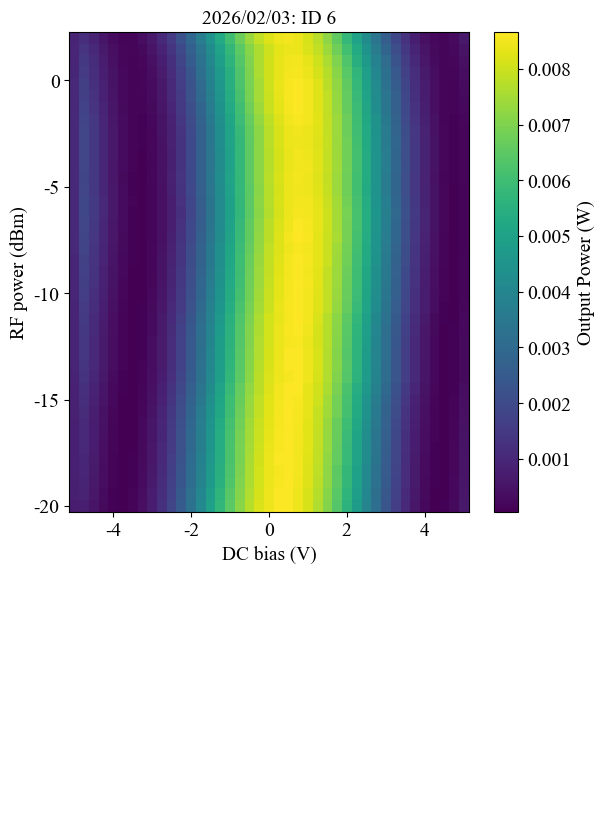

In [64]:
ps.Plot3D(x = RF_power_list, y = bias_list, Z = np.array(output_power),
          xlabel = "RF power (dBm)", ylabel = "DC bias (V)", zlabel = "Output Power (W)",transpose=True)  

In [66]:
pm.close()

In [65]:
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

Channel 11 has been set to 0 V.


In [68]:
rm.list_opened_resources()

[]